# STEM Image Denoising with MCNN and OpenVINO™

[MCNN](https://github.com/fengwang/MCNN) (Multi-Resolution Convolutional Neural Network) is a deep model for denoising High-Angle Annular Dark-Field Scanning Transmission Electron Microscopy (HAADF-STEM) images. A STEM image acquired at low electron dose is dominated by salt-and-pepper noise that buries the real signal — the positions of atomic columns. MCNN learns to map the noisy image back to a clean reconstruction of the atomic structure.

The original model ships in Keras / TensorFlow 1.x, which no longer runs on modern Python. This notebook uses a maintained fork, [dhandhalyabhavik/MCNN-ov](https://github.com/dhandhalyabhavik/MCNN-ov), that re-implements the trained model in PyTorch (loading the original weights directly from the Keras H5 with `h5py`, no TensorFlow), and demonstrates converting it to OpenVINO IR, quantizing it to INT8, and comparing FP16 and INT8 on Intel CPU and GPU.

You can find more information about this model in the [research paper](https://doi.org/10.1038/s41598-020-62484-z) and the original GitHub [repository](https://github.com/fengwang/MCNN).

The notebook contains the following steps:

1. Prepare the PyTorch model (from the fork's ported weights).
2. Prepare data and run PyTorch inference (noisy → denoised).
3. Convert the model to OpenVINO IR (FP16).
4. Run OpenVINO inference on CPU / GPU.
5. Quantize the model to INT8 (weight-only) with NNCF.
6. Compare the FP16 and INT8 models (performance and accuracy).

This model runs on Intel **CPU** and **GPU** (NPU is not used).

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Prepare PyTorch model](#Prepare-PyTorch-model)
    - [Prepare data](#Prepare-data)
- [Run PyTorch model inference](#Run-PyTorch-model-inference)
- [Convert model to OpenVINO IR](#Convert-model-to-OpenVINO-IR)
    - [Select inference device](#Select-inference-device)
    - [Compile model and run inference](#Compile-model-and-run-inference)
- [Quantize model to INT8 with NNCF](#Quantize-model-to-INT8-with-NNCF)
    - [Validate INT8 model inference](#Validate-INT8-model-inference)
    - [Run denoising with selected precision](#Run-denoising-with-selected-precision)
- [Compare the Original and Quantized Models](#Compare-the-Original-and-Quantized-Models)
    - [Compare performance](#Compare-performance)
    - [Compare accuracy](#Compare-accuracy)

Installation Instructions:

This is a self-contained example that relies solely on its own code.

We recommend running the notebook in a virtual environment. You only need a Jupyter server to start. For details, please refer to [Installation Guide](../../README.md).

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install required dependencies.

In [ ]:
%pip install -q "openvino>=2025.1.0" "nncf>=2.16.0" "torch>=2.4" "torchvision" --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "h5py>=3.10" "scipy>=1.10" "opencv-python" "matplotlib>=3.4" "numpy" "ipywidgets" "requests" "Pillow"

In [2]:
from pathlib import Path
import requests

# Fetch helper modules from the openvino_notebooks utils folder
helpers = ["notebook_utils.py", "cmd_helper.py", "skip_kernel_extension.py"]
for file_name in helpers:
    if not Path(file_name).exists():
        r = requests.get(
            url=f"https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/{file_name}",
        )
        open(file_name, "w").write(r.text)

from notebook_utils import device_widget, quantization_widget

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("mcnn-denoising.ipynb")

## Prepare PyTorch model
[back to top ⬆️](#Table-of-contents:)

We clone the [MCNN-ov](https://github.com/dhandhalyabhavik/MCNN-ov) fork, which contains the model code and the trained weights (the original Google Drive weight link is no longer available). The original 160 MB Keras weights file is stored as split parts to stay under GitHub's file-size limit, so we reassemble it first, then load it into the PyTorch model with `h5py` — no TensorFlow required.

In [3]:
import sys
import subprocess
from cmd_helper import clone_repo

# Clone the fork with the ported model and trained weights
model_repo = clone_repo("https://github.com/dhandhalyabhavik/MCNN-ov.git")

# Reassemble the original Keras weights from split parts
keras_weights = model_repo / "models" / "original" / "denoising.model"
if not keras_weights.exists():
    subprocess.run([sys.executable, "models/reassemble.py"], cwd=str(model_repo), check=True)

# Make the fork's model module importable
sys.path.insert(0, str((model_repo / "ov").resolve()))
from model import MCNNDenoising, load_from_keras, apply_lpf, norm01, psnr, ssim, mae

In [4]:
import torch

# Build the PyTorch model and load the trained Keras weights
model = load_from_keras(keras_weights)
model.eval()
print(f"Loaded {sum(p.numel() for p in model.parameters()):,} parameters")

Loaded 41,826,561 parameters


### Prepare data
[back to top ⬆️](#Table-of-contents:)

The model input is a 4-channel tensor produced by the author's fixed low-pass filter (LPF) preprocessor applied to the normalized noisy image. We load a noisy STEM image and its clean ground truth (used later for accuracy), build the model input, and define a small helper to display images.

model input shape: (1, 4, 512, 512)


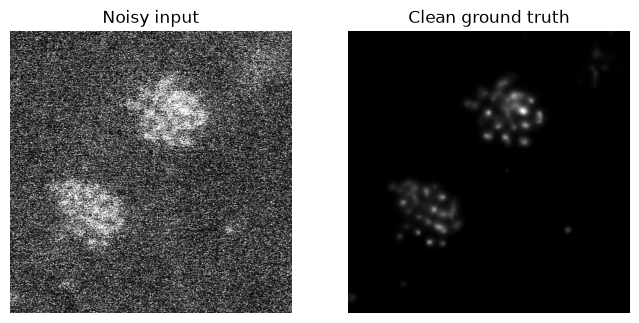

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

lpf_model = model_repo / "models" / "original" / "lpf.model"
noisy_path = model_repo / "ov" / "data" / "noisy_512x512.png"
clean_path = model_repo / "ov" / "data" / "clear_512x512.png"

noisy_u = cv2.imread(str(noisy_path), cv2.IMREAD_UNCHANGED)
clean_u = cv2.imread(str(clean_path), cv2.IMREAD_UNCHANGED)
noisy01 = norm01(noisy_u.astype(np.float32))
clean01 = norm01(clean_u.astype(np.float32))

# LPF preprocessing -> (1, 4, 512, 512) float32 model input
model_input = apply_lpf(noisy01, lpf_model)[np.newaxis].astype(np.float32)
print("model input shape:", model_input.shape)


def show_images(images, titles, suptitle=None):
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4.2))
    for ax, im, t in zip(axes, images, titles):
        ax.imshow(im, cmap="gray", vmin=0, vmax=1)
        ax.set_title(t)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle)
    plt.show()


show_images([noisy01, clean01], ["Noisy input", "Clean ground truth"])

## Run PyTorch model inference
[back to top ⬆️](#Table-of-contents:)

Run a forward pass through the PyTorch model to produce the denoised image. This is our reference output.

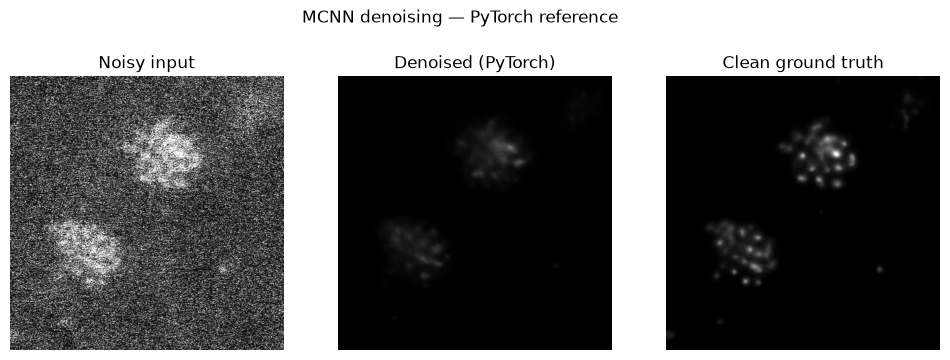

In [6]:
with torch.no_grad():
    pt_out = model(torch.from_numpy(model_input)).squeeze().numpy()

show_images([noisy01, pt_out, clean01],
            ["Noisy input", "Denoised (PyTorch)", "Clean ground truth"],
            suptitle="MCNN denoising — PyTorch reference")

## Convert model to OpenVINO IR
[back to top ⬆️](#Table-of-contents:)

Convert the PyTorch model to OpenVINO IR. An OpenVINO IR model consists of an `.xml` file (network topology) and a `.bin` file (weights). `ov.convert_model` returns an OpenVINO model ready to compile, and `ov.save_model` serializes it with FP16 weight compression.

In [7]:
import openvino as ov

core = ov.Core()

ov_dir = Path("ov_model")
ov_dir.mkdir(exist_ok=True)
fp16_xml = ov_dir / "mcnn_fp16.xml"

# Convert (keep the FP32 model in memory as the source for INT8 later)
ov_model = ov.convert_model(model, example_input=torch.randn(1, 4, 512, 512),
                            input=[ov.PartialShape([1, 4, 512, 512])])
ov.save_model(ov_model, str(fp16_xml), compress_to_fp16=True)
print(f"Saved FP16 IR: {fp16_xml} ({fp16_xml.with_suffix('.bin').stat().st_size / 1048576:.1f} MB)")

# INT8 model path (defined unconditionally so later cells can reference it)
int8_xml = ov_dir / "mcnn_int8.xml"

Saved FP16 IR: ov_model/mcnn_fp16.xml (79.8 MB)


### Select inference device
[back to top ⬆️](#Table-of-contents:)

Select the device from the dropdown for running inference. NPU is excluded — this model targets Intel CPU and GPU.

In [8]:
device = device_widget(exclude=["NPU"])
device

Dropdown(description='Device:', index=3, options=('CPU', 'GPU.0', 'GPU.1', 'AUTO'), value='AUTO')

### Compile model and run inference
[back to top ⬆️](#Table-of-contents:)

Compile the FP16 model on the selected device and run inference. The result matches the PyTorch reference.

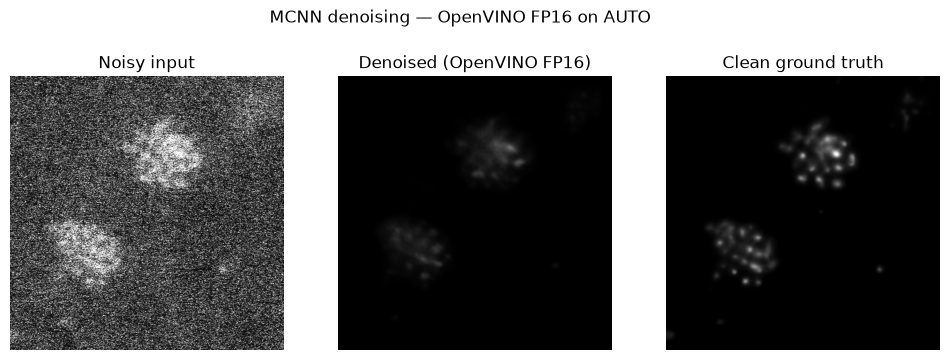

In [9]:
compiled_fp16 = core.compile_model(str(fp16_xml), device.value)
ov_fp16_out = compiled_fp16(model_input)[0].squeeze()

show_images([noisy01, ov_fp16_out, clean01],
            ["Noisy input", "Denoised (OpenVINO FP16)", "Clean ground truth"],
            suptitle=f"MCNN denoising — OpenVINO FP16 on {device.value}")

## Quantize model to INT8 with NNCF
[back to top ⬆️](#Table-of-contents:)

[NNCF](https://github.com/openvinotoolkit/nncf) provides model optimization for OpenVINO. For most models, 8-bit **post-training quantization** (`nncf.quantize`, which quantizes both weights and activations) is the standard choice.

MCNN, however, is a special case. Its denoised output is *sparse* (mostly dark, with rare bright atomic columns), and the 7-level U-Net with skip connections produces high-dynamic-range intermediate activations. Full activation quantization saturates the final sigmoid to a constant output — the model collapses. We therefore use **weight-only INT8 quantization** (`nncf.compress_weights`), which keeps activations in floating point. This is essentially lossless here (~0.03 dB) and still halves the model size versus FP16.

Select below whether to run quantization.

In [10]:
to_quantize = quantization_widget()
to_quantize

Checkbox(value=True, description='Quantization')

Load the `skip_kernel_extension` so the INT8 cells are skipped if quantization is disabled.

In [11]:
%load_ext skip_kernel_extension

In [12]:
%%skip not $to_quantize.value

import nncf

ov_int8 = nncf.compress_weights(ov_model, mode=nncf.CompressWeightsMode.INT8_SYM)
ov.save_model(ov_int8, str(int8_xml))
print(f"Saved INT8 IR: {int8_xml} ({int8_xml.with_suffix('.bin').stat().st_size / 1048576:.1f} MB)")

INFO:nncf:Statistics of the bitwidth distribution:
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┑
│ Weight compression mode   │ % all parameters (layers)   │ % ratio-defining parameters (layers)   │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┥
│ int8_sym, per-channel     │ 100% (14 / 14)              │ 100% (14 / 14)                         │
┕━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┙


Output()

Saved INT8 IR: ov_model/mcnn_int8.xml (39.9 MB)


### Validate INT8 model inference
[back to top ⬆️](#Table-of-contents:)

Run the INT8 model and confirm the denoised output is visually the same as FP16.

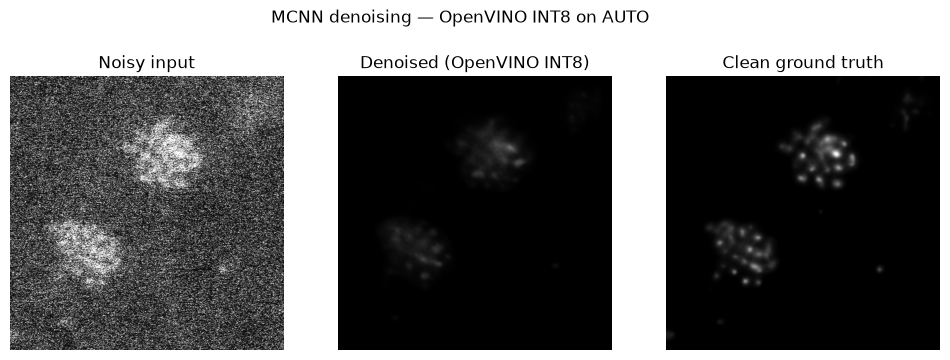

In [13]:
%%skip not $to_quantize.value

compiled_int8 = core.compile_model(str(int8_xml), device.value)
ov_int8_out = compiled_int8(model_input)[0].squeeze()

show_images([noisy01, ov_int8_out, clean01],
            ["Noisy input", "Denoised (OpenVINO INT8)", "Clean ground truth"],
            suptitle=f"MCNN denoising — OpenVINO INT8 on {device.value}")

### Run denoising with selected precision
[back to top ⬆️](#Table-of-contents:)

Pick a precision from the dropdown and run the noisy → denoised flow with it.

In [14]:
import ipywidgets as widgets

precision = widgets.Dropdown(options=["FP16", "INT8"], value="FP16", description="Precision:")
precision

Dropdown(description='Precision:', options=('FP16', 'INT8'), value='FP16')

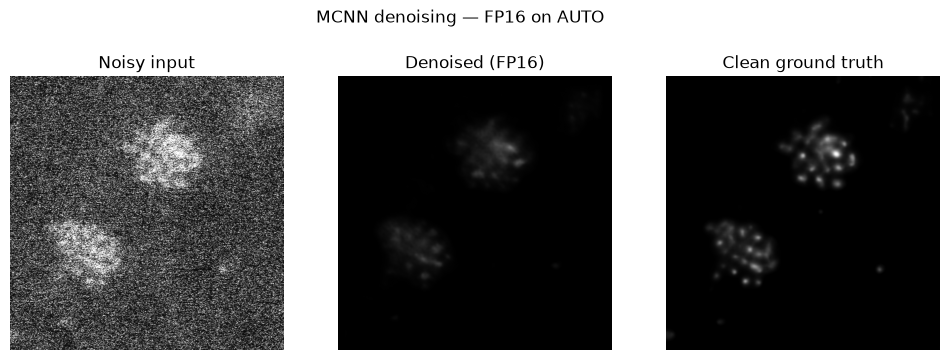

In [15]:
int8_xml = ov_dir / "mcnn_int8.xml"
selected_xml = int8_xml if (precision.value == "INT8" and int8_xml.exists()) else fp16_xml

compiled_sel = core.compile_model(str(selected_xml), device.value)
sel_out = compiled_sel(model_input)[0].squeeze()

show_images([noisy01, sel_out, clean01],
            ["Noisy input", f"Denoised ({precision.value})", "Clean ground truth"],
            suptitle=f"MCNN denoising — {precision.value} on {device.value}")

## Compare the Original and Quantized Models
[back to top ⬆️](#Table-of-contents:)

### Compare performance
[back to top ⬆️](#Table-of-contents:)

Use the OpenVINO [Benchmark Tool](https://docs.openvino.ai/2024/learn-openvino/openvino-samples/benchmark-tool.html) to measure the inference performance of the FP16 and INT8 models.

> **Note**: For more accurate performance, run `benchmark_app` in a terminal after closing other applications. Run `benchmark_app --help` to see all options.

In [16]:
device

Dropdown(description='Device:', index=3, options=('CPU', 'GPU.0', 'GPU.1', 'AUTO'), value='AUTO')

In [17]:
!benchmark_app -m $fp16_xml -d $device.value -api async -shape "[1,4,512,512]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2025.4.1-20426-82bbf0292c5-releases/2025/4
[ INFO ] 
[ INFO ] Device info:
[ INFO ] AUTO
[ INFO ] Build ................................. 2025.4.1-20426-82bbf0292c5-releases/2025/4
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line or config file. Device(AUTO) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 14.06 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : f32 / [...] / [1,4,512,512]
[ INFO ] Model outputs:
[ INFO ]     ***NO_NAME*** (node: __module.head_512/aten::sigmoid/Sigmoid) : f32 / [...] / [1,1,512,512]
[Step 5/11] Resizing model to match image sizes and given batch

[ INFO ] Compile model took 428.14 ms
[ INFO ] Start of compilation memory usage: Peak 20289148 KB
[ INFO ] End of compilation memory usage: Peak 1132608556 KB
[ INFO ] Compile model ram used 1112319408 KB
[Step 8/11] Querying optimal runtime parameters
[ INFO ] Model:
[ INFO ]   NETWORK_NAME: Model0
[ INFO ]   EXECUTION_DEVICES: ['(CPU)']
[ INFO ]   PERFORMANCE_HINT: PerformanceMode.THROUGHPUT


[ INFO ]   OPTIMAL_NUMBER_OF_INFER_REQUESTS: 4
[ INFO ]   MULTI_DEVICE_PRIORITIES: GPU.0,GPU.1,CPU
[ INFO ]   CPU:
[ INFO ]     CPU_DENORMALS_OPTIMIZATION: False
[ INFO ]     CPU_SPARSE_WEIGHTS_DECOMPRESSION_RATE: 1.0
[ INFO ]     DYNAMIC_QUANTIZATION_GROUP_SIZE: 32
[ INFO ]     ENABLE_CPU_PINNING: True
[ INFO ]     ENABLE_CPU_RESERVATION: False
[ INFO ]     ENABLE_HYPER_THREADING: False
[ INFO ]     ENABLE_TENSOR_PARALLEL: False
[ INFO ]     EXECUTION_DEVICES: ['CPU']
[ INFO ]     EXECUTION_MODE_HINT: ExecutionMode.PERFORMANCE
[ INFO ]     INFERENCE_NUM_THREADS: 48
[ INFO ]     INFERENCE_PRECISION_HINT: <Type: 'bfloat16'>
[ INFO ]     KEY_CACHE_GROUP_SIZE: 0
[ INFO ]     KEY_CACHE_PRECISION: <Type: 'uint8_t'>
[ INFO ]     KV_CACHE_PRECISION: <Type: 'uint8_t'>
[ INFO ]     LOG_LEVEL: Level.NO
[ INFO ]     MODEL_DISTRIBUTION_POLICY: set()
[ INFO ]     NETWORK_NAME: Model0
[ INFO ]     NUM_STREAMS: 1
[ INFO ]     OPTIMAL_NUMBER_OF_INFER_REQUESTS: 1
[ INFO ]     PERFORMANCE_HINT: LATENCY


[ WARNING ] No input files were given for input 'x'!. This input will be filled with random values!
[ INFO ] Fill input 'x' with random values 


[Step 10/11] Measuring performance (Start inference asynchronously, 4 inference requests, limits: 15000 ms duration)
[ INFO ] Benchmarking in inference only mode (inputs filling are not included in measurement loop).
[ INFO ] First inference took 8.78 ms


[Step 11/11] Dumping statistics report
[ INFO ] Execution Devices:['GPU.0']
[ INFO ] Count:            3252 iterations
[ INFO ] Duration:         15020.38 ms
[ INFO ] Latency:
[ INFO ]    Median:        18.27 ms
[ INFO ]    Average:       18.28 ms
[ INFO ]    Min:           7.83 ms
[ INFO ]    Max:           28.97 ms
[ INFO ] Throughput:   216.51 FPS


In [18]:
if int8_xml.exists():
    !benchmark_app -m $int8_xml -d $device.value -api async -shape "[1,4,512,512]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2025.4.1-20426-82bbf0292c5-releases/2025/4
[ INFO ] 
[ INFO ] Device info:
[ INFO ] AUTO
[ INFO ] Build ................................. 2025.4.1-20426-82bbf0292c5-releases/2025/4
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line or config file. Device(AUTO) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 14.47 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : f32 / [...] / [1,4,512,512]
[ INFO ] Model outputs:
[ INFO ]     ***NO_NAME*** (node: __module.head_512/aten::sigmoid/Sigmoid) : f32 / [...] / [1,1,512,512]
[Step 5/11] Resizing model to match image sizes and given batch

[ INFO ] Compile model took 964.28 ms
[ INFO ] Start of compilation memory usage: Peak 20248296 KB
[ INFO ] End of compilation memory usage: Peak 1123228748 KB
[ INFO ] Compile model ram used 1102980452 KB
[Step 8/11] Querying optimal runtime parameters
[ INFO ] Model:
[ INFO ]   NETWORK_NAME: Model0
[ INFO ]   EXECUTION_DEVICES: ['GPU.0']
[ INFO ]   PERFORMANCE_HINT: PerformanceMode.THROUGHPUT
[ INFO ]   OPTIMAL_NUMBER_OF_INFER_REQUESTS: 4
[ INFO ]   MULTI_DEVICE_PRIORITIES: GPU.0,GPU.1,CPU
[ INFO ]   GPU.0:
[ INFO ]     AUTO_BATCH_TIMEOUT: 1000
[ INFO ]     EXECUTION_DEVICES: ['GPU.0']
[ INFO ]     NETWORK_NAME: Model0
[ INFO ]     OPTIMAL_NUMBER_OF_INFER_REQUESTS: 4
[ INFO ]   MODEL_PRIORITY: Priority.MEDIUM
[ INFO ]   LOADED_FROM_CACHE: False
[ INFO ]   PERF_COUNT: False
[Step 9/11] Creating infer requests and preparing input tensors
[ WARNING ] No input files were given for input 'x'!. This input will be filled with random values!
[ INFO ] Fill input 'x' with random values 


[Step 10/11] Measuring performance (Start inference asynchronously, 4 inference requests, limits: 15000 ms duration)
[ INFO ] Benchmarking in inference only mode (inputs filling are not included in measurement loop).


[ INFO ] First inference took 12.76 ms


[Step 11/11] Dumping statistics report
[ INFO ] Execution Devices:['GPU.0']
[ INFO ] Count:            3304 iterations
[ INFO ] Duration:         15022.69 ms
[ INFO ] Latency:
[ INFO ]    Median:        17.87 ms
[ INFO ]    Average:       17.94 ms
[ INFO ]    Min:           9.27 ms
[ INFO ]    Max:           40.33 ms
[ INFO ] Throughput:   219.93 FPS


### Compare accuracy
[back to top ⬆️](#Table-of-contents:)

Compare the denoising quality (PSNR and SSIM versus the clean ground truth) across the noisy baseline, the PyTorch reference, and the OpenVINO FP16 and INT8 models. Higher PSNR/SSIM is better.

In [19]:
rows = [
    ("Noisy (baseline)", noisy01),
    ("PyTorch FP32",     pt_out),
    ("OpenVINO FP16",    ov_fp16_out),
]
if (ov_dir / "mcnn_int8.xml").exists():
    out8 = core.compile_model(str(ov_dir / "mcnn_int8.xml"), device.value)(model_input)[0].squeeze()
    rows.append(("OpenVINO INT8", out8))

print(f"{'Model':<20}{'PSNR (dB)':>12}{'SSIM':>10}")
print("-" * 42)
for name, img in rows:
    print(f"{name:<20}{psnr(img, clean01):>12.2f}{ssim(img, clean01):>10.4f}")

Model                  PSNR (dB)      SSIM
------------------------------------------


Noisy (baseline)            8.47    0.0025


PyTorch FP32               28.57    0.9223
OpenVINO FP16              28.57    0.9224


OpenVINO INT8              28.54    0.9226


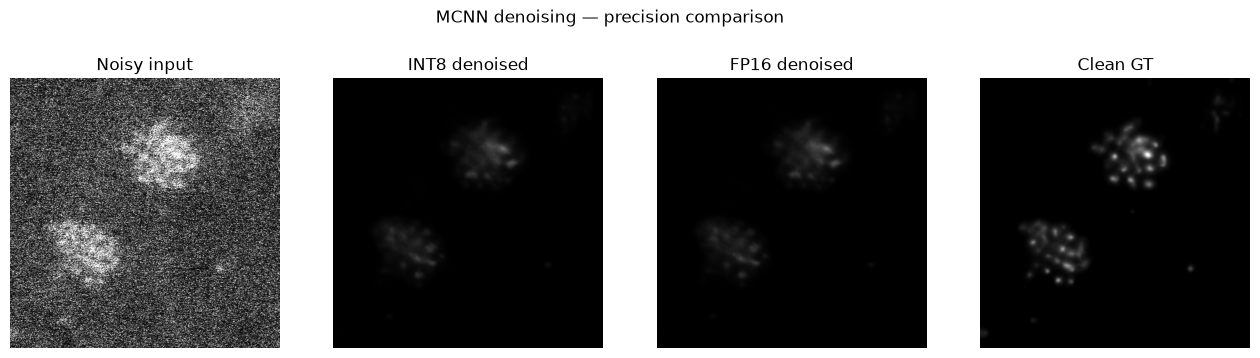

In [20]:
imgs = [noisy01]
titles = ["Noisy input"]
if (ov_dir / "mcnn_int8.xml").exists():
    imgs.append(out8); titles.append("INT8 denoised")
imgs.append(ov_fp16_out); titles.append("FP16 denoised")
imgs.append(clean01); titles.append("Clean GT")

show_images(imgs, titles, suptitle="MCNN denoising — precision comparison")